## Wildfire Prediction Models
Khushi Khan, Ella Chee, Willbert Clement Christianto  
DS4420: Machine Learning and Data Mining 2

In [1]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras
import tensorflow as tf
import os

# keras contains the tensorflow package
from keras.models import Model
from keras.layers import Dense, Input, Rescaling
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.optimizers import SGD
from keras.losses import binary_crossentropy

### Loading datasets

In [2]:
# Tracking all path files
data_root = Path("../data/raw")
num_channels = 3

def scan_dataset(directory):
    bad_files = []
    all_files = list(Path(directory).rglob("*.jpg")) + \
                list(Path(directory).rglob("*.jpeg")) + \
                list(Path(directory).rglob("*.png"))
    
    print(f"Scanning {len(all_files)} files in {directory}...")
    
    for path in all_files:
        try:
            with Image.open(path) as img:
                img.verify()
            with Image.open(path) as img:
                img.load()
        except Exception as e:
            print(f"Bad file: {path} — {e}")
            bad_files.append(path)
    
    return bad_files

bad_train = scan_dataset(data_root / "train")
bad_test = scan_dataset(data_root / "test")

all_bad = bad_train + bad_test
print(f"\nTotal bad files: {len(all_bad)}")

for path in all_bad:
    os.remove(path)  # or move to a /bad_files/ folder if you want to inspect them
    print(f"Removed: {path}")

Scanning 30249 files in ..\data\raw\train...
Scanning 6299 files in ..\data\raw\test...

Total bad files: 0


In [3]:
# Load the images into a dataset
# - Infers subfolder labels (0 or 1)
# - Resizes images to (256, 256)
# - Color mode is RGB
# Documentation: https://keras.io/api/data_loading/image/
train_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "train"), labels='inferred')
test_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "test"), labels='inferred')
# valid_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "valid"), labels='inferred')

Found 30249 files belonging to 2 classes.
Found 6299 files belonging to 2 classes.


In [4]:
# Checking that class names are correct
class_names = train_dataset.class_names
print(class_names)

['nowildfire', 'wildfire']


### Visualizing the training dataset and labels

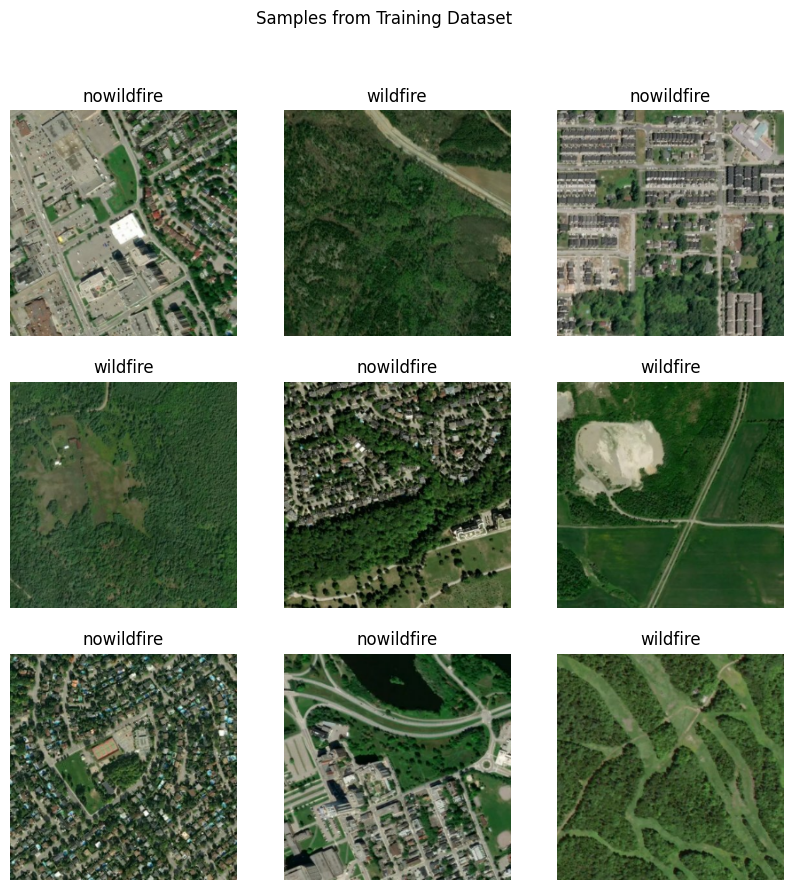

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.suptitle("Samples from Training Dataset")
    plt.show()

### Inspecting tensor shapes

In [6]:
print(train_dataset.element_spec)
print(test_dataset.element_spec)

(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [7]:
# Configuring the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

### Building the CNN

In [8]:
num_classes = len(class_names)

img_dim = (256, 256)

# Instantiating a Keras tensor
inpx = Input(shape=(img_dim[0], img_dim[1], num_channels))

# Normalizing the data to be between 0 and 1
inpx = Rescaling(1./255, (img_dim[0], img_dim[1], num_channels))(inpx)

# Instantiating first convolutional and pooling layer
conv_layer = Conv2D(1, kernel_size=(3,3), strides=1, activation=None)(inpx)
pool_layer = MaxPooling2D(pool_size=(3,3))(conv_layer)

# Instantiating second convolutional and pooling layer
conv_layer2 = Conv2D(1, kernel_size=(3,3), strides=1, activation='sigmoid')(pool_layer)
pool_layer2 = MaxPooling2D(pool_size=(3,3))(conv_layer2)

# Flattening the images for the hidden layer/output
flat_G = Flatten()(conv_layer2)

# Defining first hidden layer
hid_layer = Dense(250, activation='relu')(flat_G)

# Defining output layer
out_layer = Dense(1, activation='sigmoid')(hid_layer)

In [9]:
model = Model([inpx], out_layer)

# Compile the model
model.compile(
    optimizer=SGD(),
    loss=binary_crossentropy,
    metrics=[
        'accuracy',
        keras.metrics.TruePositives(name='tp'),
        keras.metrics.FalsePositives(name='fp'),
        keras.metrics.TrueNegatives(name='tn'),
        keras.metrics.FalseNegatives(name='fn')
    ]
)

In [10]:
# View all the layers of the CNN
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_1CLONE             │ (None, 256, 256, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 1)    │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 84, 84, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 82, 82, 1)      │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6724)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 250)            │     1,681,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681,539 (6.41 MB)

 Trainable params: 1,681,539 (6.41 MB)

 Non-trainable params: 0 (0.00 B)

### Training the CNN

In [11]:
epochs = 50

history = model.fit(
    train_dataset,
    batch_size=32,
    epochs=epochs
)

Epoch 1/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 70s 46ms/step - accuracy: 0.8013 - fn: 2657.0000 - fp: 3354.0000 - loss: 0.4606 - tn: 11145.0000 - tp: 13093.0000
Epoch 2/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8718 - fn: 1461.0000 - fp: 2418.0000 - loss: 0.3290 - tn: 12081.0000 - tp: 14289.0000
Epoch 3/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8851 - fn: 1392.0000 - fp: 2085.0000 - loss: 0.2954 - tn: 12414.0000 - tp: 14358.0000
Epoch 4/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8924 - fn: 1305.0000 - fp: 1951.0000 - loss: 0.2768 - tn: 12548.0000 - tp: 14445.0000
Epoch 5/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8958 - fn: 1268.0000 - fp: 1884.0000 - loss: 0.2680 - tn: 12615.0000 - tp: 14482.0000
Epoch 6/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8991 - fn: 1241.0000 - fp: 1812.0000 - loss: 0.2601 - tn: 12687.0000 - tp: 14509.0000
Epoch 7/50
946/946 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9026 - f

### Evaluating the model's performance on the test data and examining performance metrics

In [12]:
score = model.evaluate(test_dataset)

model_metrics = {
    'Loss': round(score[0], 4),
    'Accuracy': round(score[1], 4),
    'True positives': score[2],
    'False positives': score[3],
    'True negatives': score[4],
    'False negatives': score[5]
}

for metric, score in model_metrics.items():
    print(f"{metric}: {score}")

197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8852 - fn: 425.0000 - fp: 298.0000 - loss: 0.4210 - tn: 2522.0000 - tp: 3054.0000
Loss: 0.421
Accuracy: 0.8852
True positives: 3054.0
False positives: 298.0
True negatives: 2522.0
False negatives: 425.0


It seems like the model is performing quite well. The majority of its predictions are true positives and negatives. It has a high accuracy of 88% on the test dataset.

### Saving the model

In [ ]:
try:
    model.save('./cnn_model.keras')
    print("Model saved!")
except Exception as e:
    print(f"Error while saving model: {e}")

# how to load the model back:
# model = keras.models.load_model('./cnn_model.keras')

Model saved!
